In [1]:
import ast
import cv2
import json
import torch
import random
import numpy as np
from pathlib import Path
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from kornia.geometry import resize
from torch.utils.data import Dataset

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Explorative Data Analysis for DoTA dataset

<a id="back"></a>
## Contents:
1. [Define dataset](#define-dataset)
2. [Initialize dataset](#initialize-dataset)
3. [Types of labels](#types-of-labels)
4. [Random sequence](#random-sequence)
5. [Check a frame from each class](#check-a-frame-from-each-class)
6. [Check class balance](#check-class-balance)
7. [Pixel differences between classes](#pixel-differences-between-classes)
8. [Histograms of RGB](#histograms-of-rgb)
9. [Contrast and intensity](#contrast-and-intensity)
10. [Blur](#blur)
11. [Grayscale intensity distribution](#grayscale-intensity-distribution)
12. [Optical flow analysis](#optical-flow-analysis)

### Define dataset

In [8]:
class SupervisedDataset(Dataset):
    def __init__(self, path_to_data: str, which_set: str, resize_target: tuple = (227, 227), target_class: str | int = 'all', crop_type: str = None, dataset_name: str = 'DoTA', color: str = 'rgb'):

        assert which_set in ['train', 'val', 'test'], f"which_set must be one of ['train', 'val', 'test'], got {which_set}"

        self.path_to_data = Path(path_to_data)
        self.resize_target = resize_target
        self.target_class = target_class
        self.crop_type = crop_type
        self.color = color
        self.which_set = which_set
        self.dataset_name = dataset_name
        self.images, self.labels = self.load_data(dataset_name, which_set)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image_path = str(self.images[idx])
        img = cv2.imread(image_path) # type: ignore
        if self.color == 'rgb':
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        elif self.color == 'gray':
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        else:
            raise ValueError(f"Invalid color: {self.color}")
        
        if img is None:
            raise ValueError(f"Could not load image from path: {image_path}")
        
        img = torch.tensor(img)
        if self.crop_type:
            if self.crop_type == 'manual':
                img = img[300:-100]
        if len(img.shape) == 2:
            img = img.unsqueeze(2)
        img = img.permute(2, 0, 1).float() / 255.
        img = resize(img, self.resize_target)

        return img, self.labels[idx]

    def _load_dota(self, which_set: str):
        label_paths = [label for label in (self.path_to_data / 'annotations' / which_set).rglob('*.json')]
        images = []
        targets = []
        for label_path in label_paths:
            with open(label_path, 'r', encoding='utf-8') as f:
                labels_data = json.load(f)
                if "labels" not in labels_data:
                    print(f"Warning: Key 'labels' not found in file {label_path}. Skipping file.")
                    continue
                labels = labels_data["labels"]

                try:
                    labels.sort(key=lambda x: x['image_path'])
                except KeyError:
                    print(f"Warning: Key 'image_path' not found in one of the labels in file {label_path}. Sorting skipped.")
                except Exception as e:
                    print(f"Error while sorting labels in file {label_path}: {e}. Sorting skipped.")

                temp_images_for_file = []
                temp_targets_for_file = []

                for label in labels:
                    image_path_str = label.get('image_path')

                    if image_path_str is None:
                        print(f"Warning: Key 'image_path' not found in label in file {label_path}. Skipping label.")
                        continue

                    image_path = self.path_to_data / "frames" / which_set / image_path_str.replace("frames/", "")

                    if not image_path.exists():
                        continue

                    original_accident_id = label.get('accident_id', -1)
                    
                    if original_accident_id == 0:
                        mapped_id = 0
                    elif original_accident_id in [1, 2, 3, 4, 5]:
                        mapped_id = 1
                    elif original_accident_id == 6:
                        mapped_id = 2
                    elif original_accident_id == 7:
                        mapped_id = 3
                    elif original_accident_id in [8, 9]:
                        mapped_id = 4
                    elif original_accident_id == 10:
                        mapped_id = 5
                    else:
                         continue

                    # Filter based on target_class parameter
                    if self.target_class == 'all':
                        # Include all classes
                        should_include = True
                    elif isinstance(self.target_class, int):
                        # Include only class 0 and the specified target_class
                        should_include = mapped_id == 0 or mapped_id == self.target_class
                    else:
                        # Invalid target_class value, skip
                        should_include = False

                    if not should_include:
                        continue

                    if mapped_id != 0:
                        temp_images_for_file.append(image_path)
                        temp_targets_for_file.append(mapped_id)
                    else:
                        #if seen_anomaly_in_file: # Odkomentować później
                        #    break
                        #else:
                        temp_images_for_file.append(image_path)
                        temp_targets_for_file.append(0)

            images.extend(temp_images_for_file)
            targets.extend(temp_targets_for_file)

        if not images:
            raise ValueError(f"No valid image files found in the set {which_set}")

        return images, torch.tensor(targets)
    
    def _load_carcrash(self, which_set: str):
        # Read labels from labels.txt
        labels_file = self.path_to_data / 'labels.txt'
        if not labels_file.exists():
            raise FileNotFoundError(f"Labels file not found: {labels_file}")
        
        all_data = []
        
        with open(labels_file, 'r') as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                
                # Parse the line: directory_name,[list_of_targets],other_params...
                first_comma_idx = line.find(',')
                if first_comma_idx == -1:
                    continue
                
                directory_name = line[:first_comma_idx]
                
                # Extract the list of targets - find the part between [ and ]
                start_idx = line.find('[')
                end_idx = line.find(']')
                
                if start_idx == -1 or end_idx == -1:
                    continue
                
                # Parse the list of targets
                targets_str = line[start_idx:end_idx+1]
                try:
                    targets = ast.literal_eval(targets_str)
                except:
                    continue
                
                # Check if directory exists
                frames_dir = self.path_to_data / 'frames' / 'test' / directory_name
                if not frames_dir.exists():
                    continue
                
                # Get all image files in the directory
                image_files = sorted(list(frames_dir.glob('frame_*.jpg')))
                if len(image_files) == 0:
                    continue
                
                # Each entry contains: (image_path, label)
                for i, image_file in enumerate(image_files):
                    if i < len(targets):
                        label = targets[i]
                        all_data.append((image_file, label))
        
        if not all_data:
            raise ValueError("No valid data found for CarCrash dataset")
        
        # Split data into train/val/test (70:15:15) without random shuffling
        total_samples = len(all_data)
        train_size = int(0.7 * total_samples)
        val_size = int(0.15 * total_samples)
        
        if which_set == 'train':
            selected_data = all_data[:train_size]
        elif which_set == 'val':
            selected_data = all_data[train_size:train_size + val_size]
        elif which_set == 'test':
            selected_data = all_data[train_size + val_size:]
        else:
            raise ValueError(f"Invalid which_set: {which_set}")
        
        if not selected_data:
            raise ValueError(f"No data found for set: {which_set}")
        
        # Separate images and labels
        images = [item[0] for item in selected_data]
        labels = [item[1] for item in selected_data]
        
        return images, torch.tensor(labels)

    
    def load_data(self, dataset_name: str, which_set: str):
        if dataset_name == 'DoTA':
            return self._load_dota(which_set)
        elif dataset_name == 'CarCrash':
            return self._load_carcrash(which_set)
        else:
            raise ValueError(f"Dataset {dataset_name} not found")


### Initialize dataset

[go back](#back)

In [9]:
dataset_path = r"D:\MAGISTERKA\anomaly_traffic_road\datasets\DoTA"

train_dataset = SupervisedDataset(dataset_path, "train")
val_dataset = SupervisedDataset(dataset_path, "val")
test_dataset = SupervisedDataset(dataset_path, "test")

print(f"Training set length: {len(train_dataset.images)} images and {len(train_dataset.labels)} labels")
print(f"Validation set length: {len(val_dataset.images)} images and {len(val_dataset.labels)} labels")
print(f"Test set length: {len(test_dataset.images)} images and {len(test_dataset.labels)} labels")

Training set length: 334903 images and 334903 labels
Validation set length: 72093 images and 72093 labels
Test set length: 70654 images and 70654 labels


### Types of labels:

[Go back](#back)

In [4]:
train_dataset.labels.unique()

tensor([0, 1, 2, 3, 4, 5])

<a id="randomsequence"></a>
### Random sequence

[Go back](#back)

tensor(323498)


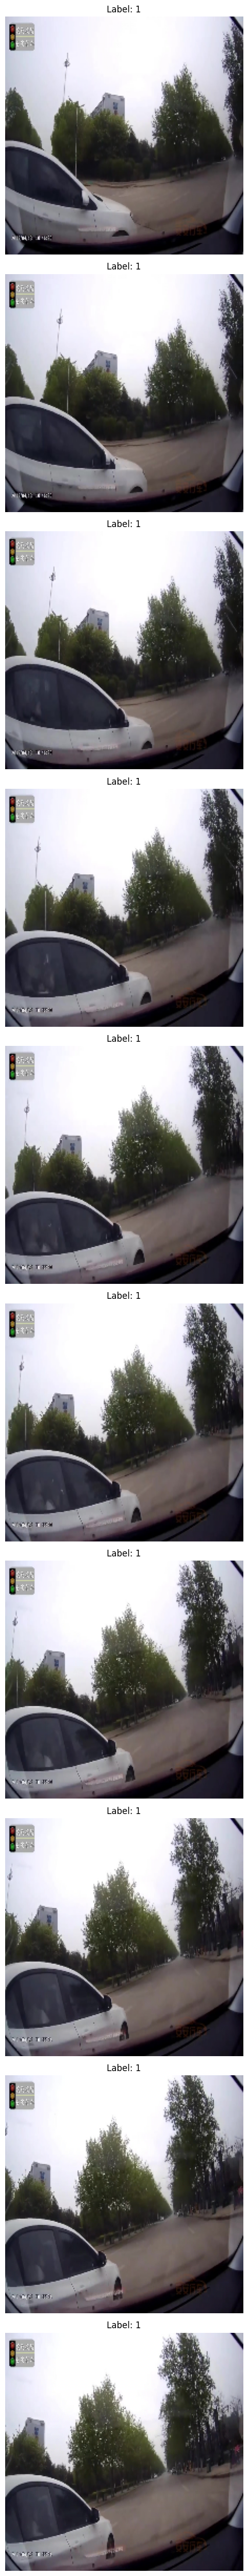

In [5]:
from random import choice

anomalies = torch.where(train_dataset.labels == 1)
idx = choice(anomalies[0])
print(idx)
fig, axs = plt.subplots(10, 1, figsize=(5, 50))
for i in range(10):
    axs[i].imshow(train_dataset[idx+i][0].permute(1, 2, 0))
    axs[i].set_title(f"Label: {train_dataset.labels[idx+i]}")
    axs[i].axis("off")
plt.tight_layout()
plt.show()

### Check a frame from each class

[Go back](#back)

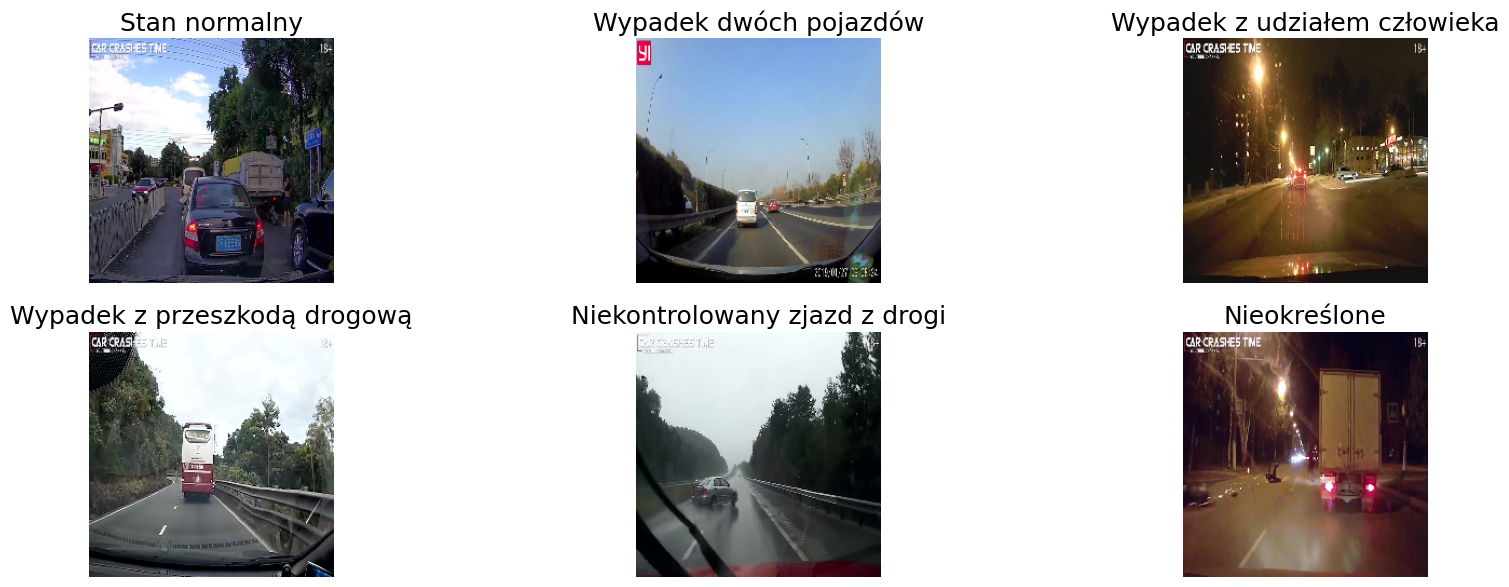

In [6]:
labels = train_dataset.labels.unique()

map_names = {
    0: "Stan normalny",
    1: "Wypadek dwóch pojazdów",
    2: "Wypadek z udziałem człowieka",
    3: "Wypadek z przeszkodą drogową",
    4: "Niekontrolowany zjazd z drogi",
    5: "Nieokreślone"
}

fig, axs = plt.subplots(2, 3, figsize=(20, 7))

id = [(0, 0), (0, 1), (0, 2), (1, 0), (1, 1), (1, 2)]

for i, label in zip(id, labels):
    indices = torch.where(train_dataset.labels == label)[0]
    idx = random.choice(indices)
    axs[i].imshow(train_dataset[idx][0].permute(1, 2, 0))
    axs[i].set_title(f"{map_names[label.item()]}", fontsize=18)
    axs[i].axis("off")

### Check class balance

[Go back](#back)

C:\Users\lukas\AppData\Local\Temp\ipykernel_52048\625619127.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  unique_labels = torch.unique(torch.tensor(labels, dtype=torch.int64))


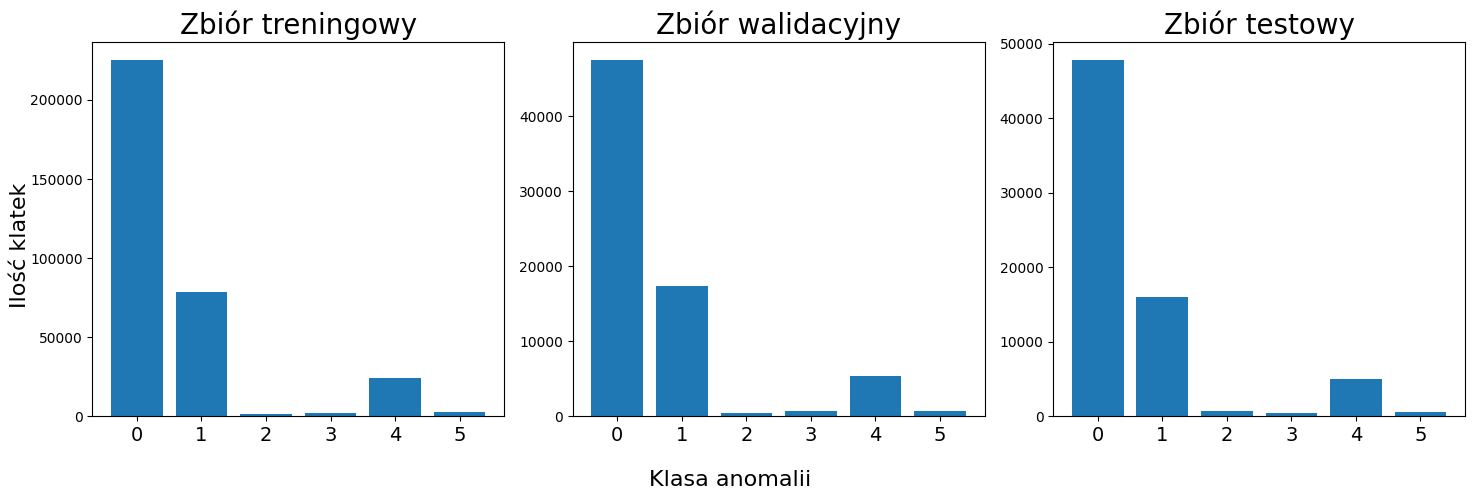

In [7]:
train_labels = train_dataset.labels.type(torch.int64)
val_labels = val_dataset.labels.type(torch.int64)
test_labels = test_dataset.labels.type(torch.int64)


fig, axs = plt.subplots(1, 3, figsize=(15, 5))

for i, labels in enumerate([train_labels, val_labels, test_labels]):
    unique_labels = torch.unique(torch.tensor(labels, dtype=torch.int64))
    class_counts = torch.bincount(labels)
    axs[i].bar(unique_labels, class_counts)
    axs[i].set_title(f"Zbiór {['treningowy', 'walidacyjny', 'testowy'][i]}", fontsize=20)
    axs[i].set_xticks(unique_labels)
    axs[i].tick_params(axis='x', labelsize=14)

# Wspólne etykiety osi
fig.supxlabel("Klasa anomalii", fontsize=16)
fig.supylabel("Ilość klatek", fontsize=16)

plt.tight_layout()
plt.show()

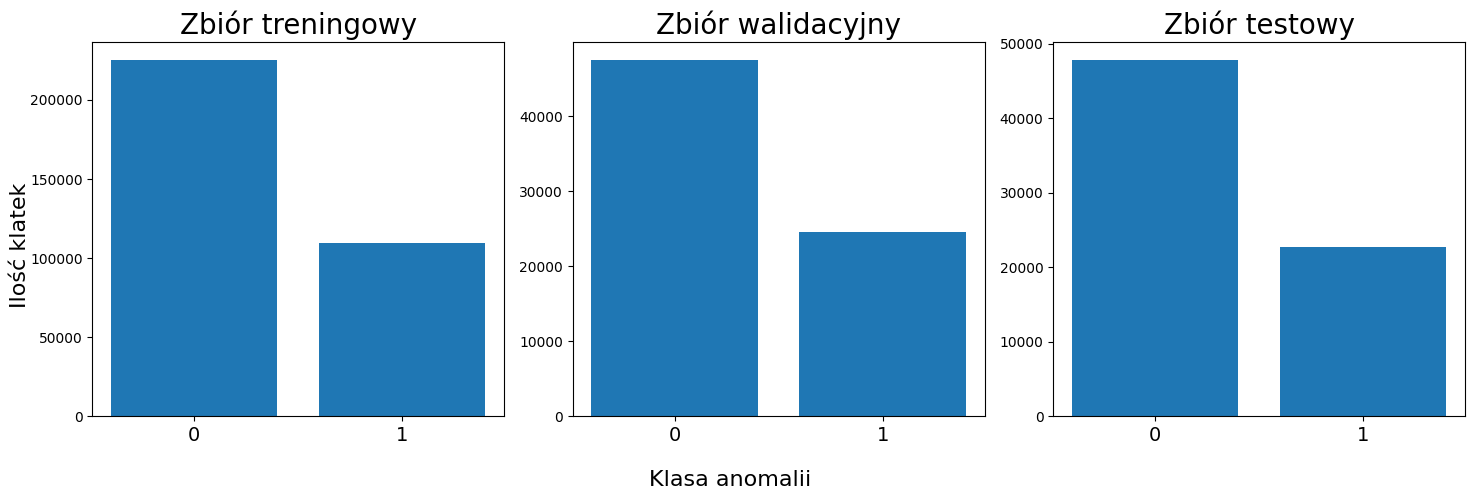

In [8]:
fig, axs = plt.subplots(1, 3, figsize=(15,5))

for i, labels in enumerate([train_labels, val_labels, test_labels]):
    unique_labels = torch.tensor([0, 1])
    class_counts = torch.bincount(labels)
    class_counts = torch.tensor([class_counts[0].item(), torch.sum(class_counts[1:]).item()])
    axs[i].bar(unique_labels, class_counts)
    axs[i].set_title(f"Zbiór {['treningowy', 'walidacyjny', 'testowy'][i]}", fontsize=20)
    axs[i].set_xticks(unique_labels)
    axs[i].tick_params(axis='x', labelsize=14)

fig.supxlabel("Klasa anomalii", fontsize=16)
fig.supylabel("Ilość klatek", fontsize=16)

plt.tight_layout()
plt.show()

### Pixel differences between classes
[Go back](#back)

  0%|          | 0/11275 [00:00<?, ?it/s]

  0%|          | 0/11275 [00:00<?, ?it/s]

  0%|          | 0/11275 [00:00<?, ?it/s]

  0%|          | 0/11274 [00:00<?, ?it/s]

  0%|          | 0/11274 [00:00<?, ?it/s]

...

  0%|          | 0/5471 [00:00<?, ?it/s]

  0%|          | 0/5471 [00:00<?, ?it/s]

  0%|          | 0/5471 [00:00<?, ?it/s]

  0%|          | 0/5471 [00:00<?, ?it/s]

  0%|          | 0/5470 [00:00<?, ?it/s]

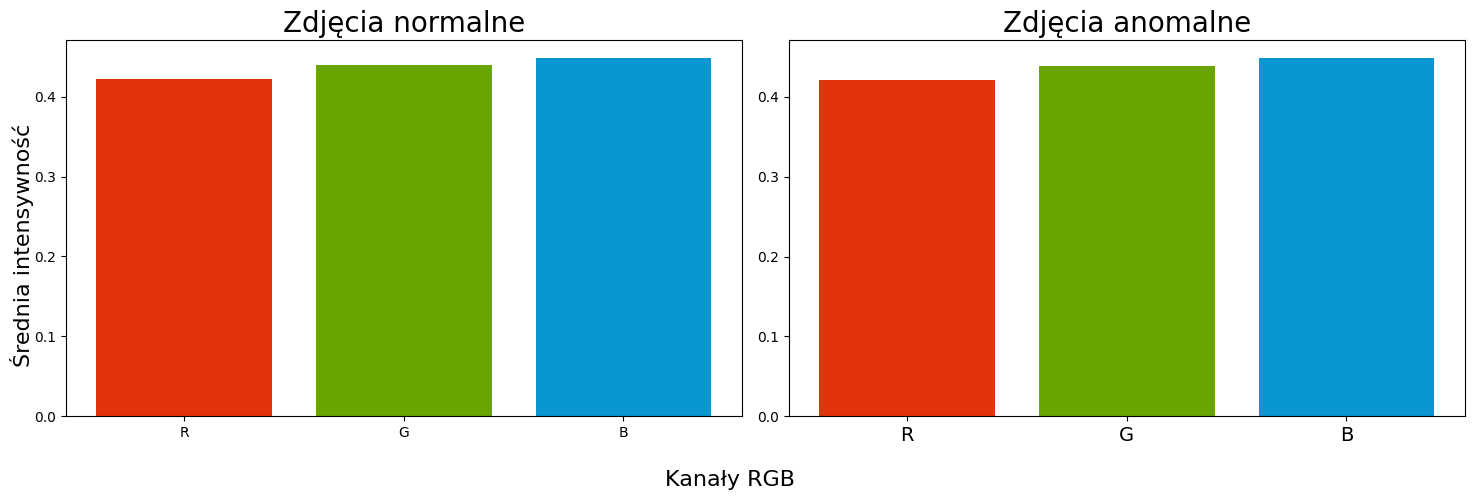

In [11]:
normal_indices = torch.where(train_labels == 0)[0]
anomaly_indices = torch.where(train_labels != 0)[0]

from concurrent.futures import ThreadPoolExecutor
import os
import matplotlib.pyplot as plt
import seaborn as sns

def calculate_mean(indices, dataset, desc=None):
    mean = torch.zeros(3, 227, 227)
    for i in tqdm(indices, desc=desc, leave=False):
        mean += dataset[i][0]
    return mean

# Podziel indeksy na mniejsze partie
def split_indices(indices, n_chunks=os.cpu_count()):
    return np.array_split(indices, n_chunks)

# Zrównoleglone obliczenia
with ThreadPoolExecutor(max_workers=os.cpu_count()) as executor:
    # Podziel indeksy na partie
    normal_chunks = split_indices(normal_indices)
    anomaly_chunks = split_indices(anomaly_indices)
    
    # Oblicz średnie dla każdej partii
    normal_means = list(executor.map(lambda chunk: calculate_mean(chunk, train_dataset), normal_chunks))
    anomaly_means = list(executor.map(lambda chunk: calculate_mean(chunk, train_dataset), anomaly_chunks))

# Zsumuj wyniki
mean_normal = sum(normal_means) / len(normal_indices)
mean_anomaly = sum(anomaly_means) / len(anomaly_indices)

mean_normal_r = mean_normal[0].mean()
mean_normal_g = mean_normal[1].mean()
mean_normal_b = mean_normal[2].mean()

mean_anomaly_r = mean_anomaly[0].mean()
mean_anomaly_g = mean_anomaly[1].mean()
mean_anomaly_b = mean_anomaly[2].mean()

# Ustawienie palety kolorów
sns.set_palette("husl")

# Kolory HEX dla lepszego wyglądu
colors_normal = ["#e3330d", "#69a501", "#0997d1"]
colors_anomaly = ["#e3330d", "#69a501", "#0997d1"]

# Tworzenie wykresów z nowymi kolorami
fig, axs = plt.subplots(1, 2, figsize=(15, 5))
axs[0].bar(range(3), [mean_normal_r, mean_normal_g, mean_normal_b], color=colors_normal)
axs[0].set_title("Zdjęcia normalne", fontsize=20)
axs[0].set_xticks(range(3), ["R", "G", "B"])

axs[1].bar(range(3), [mean_anomaly_r, mean_anomaly_g, mean_anomaly_b], color=colors_anomaly)
axs[1].set_title("Zdjęcia anomalne", fontsize=20)
axs[1].set_xticks(range(3), ["R", "G", "B"], fontsize=14)

fig.supxlabel("Kanały RGB", fontsize=16)
fig.supylabel("Średnia intensywność", fontsize=16)

plt.tight_layout()
plt.show()


  0%|          | 0/11275 [00:00<?, ?it/s]

  0%|          | 0/11275 [00:00<?, ?it/s]

  0%|          | 0/11275 [00:00<?, ?it/s]

  0%|          | 0/11275 [00:00<?, ?it/s]

  0%|          | 0/11274 [00:00<?, ?it/s]

...

  0%|          | 0/120 [00:00<?, ?it/s]

  0%|          | 0/120 [00:00<?, ?it/s]

  0%|          | 0/121 [00:00<?, ?it/s]

  0%|          | 0/120 [00:00<?, ?it/s]

  0%|          | 0/120 [00:00<?, ?it/s]

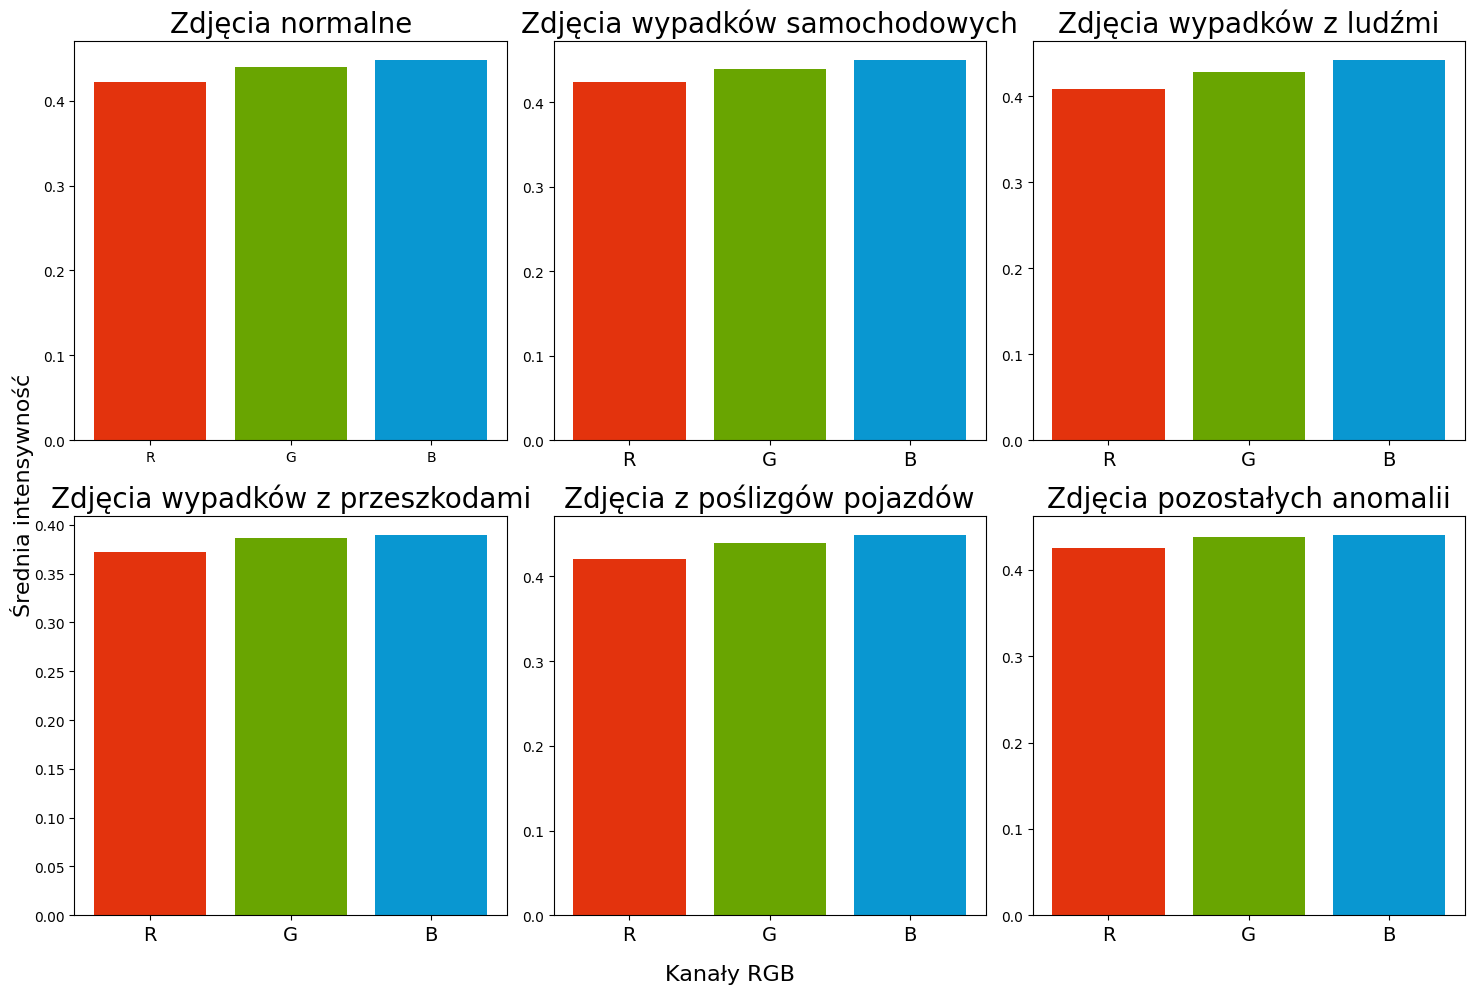

In [12]:
normal_indices = torch.where(train_labels == 0)[0]
car_crush_indices = torch.where(train_labels == 1)[0]
human_indices = torch.where(train_labels == 2)[0]
obstacle_indices = torch.where(train_labels == 3)[0]
offroad_indices = torch.where(train_labels == 4)[0]
unknown_indices = torch.where(train_labels == 5)[0]

from concurrent.futures import ThreadPoolExecutor
import os
import matplotlib.pyplot as plt
import seaborn as sns

def calculate_mean(indices, dataset, desc=None):
    mean = torch.zeros(3, 227, 227)
    for i in tqdm(indices, desc=desc, leave=False):
        mean += dataset[i][0]
    return mean

# Podziel indeksy na mniejsze partie
def split_indices(indices, n_chunks=os.cpu_count()):
    return np.array_split(indices, n_chunks)

# Zrównoleglone obliczenia
with ThreadPoolExecutor(max_workers=os.cpu_count()) as executor:
    # Podziel indeksy na partie
    normal_chunks = split_indices(normal_indices)
    car_crush_chunks = split_indices(car_crush_indices)
    human_chunks = split_indices(human_indices)
    obstacle_chunks = split_indices(obstacle_indices)
    offroad_chunks = split_indices(offroad_indices)
    unknown_chunks = split_indices(unknown_indices)
    
    # Oblicz średnie dla każdej partii
    normal_means = list(executor.map(lambda chunk: calculate_mean(chunk, train_dataset), normal_chunks))
    car_crush_means = list(executor.map(lambda chunk: calculate_mean(chunk, train_dataset), car_crush_chunks))
    human_means = list(executor.map(lambda chunk: calculate_mean(chunk, train_dataset), human_chunks))
    obstacle_means = list(executor.map(lambda chunk: calculate_mean(chunk, train_dataset), obstacle_chunks))
    offroad_means = list(executor.map(lambda chunk: calculate_mean(chunk, train_dataset), offroad_chunks))
    unknown_means = list(executor.map(lambda chunk: calculate_mean(chunk, train_dataset), unknown_chunks))

# Zsumuj wyniki
mean_normal = sum(normal_means) / len(normal_indices)
mean_car_crush = sum(car_crush_means) / len(car_crush_indices)
mean_human = sum(human_means) / len(human_indices)
mean_obstacle = sum(obstacle_means) / len(obstacle_indices)
mean_offroad = sum(offroad_means) / len(offroad_indices)
mean_unknown = sum(unknown_means) / len(unknown_indices)

mean_normal_r = mean_normal[0].mean()
mean_normal_g = mean_normal[1].mean()
mean_normal_b = mean_normal[2].mean()

mean_car_crush_r = mean_car_crush[0].mean()
mean_car_crush_g = mean_car_crush[1].mean()
mean_car_crush_b = mean_car_crush[2].mean()

mean_human_r = mean_human[0].mean()
mean_human_g = mean_human[1].mean()
mean_human_b = mean_human[2].mean()

mean_obstacle_r = mean_obstacle[0].mean()
mean_obstacle_g = mean_obstacle[1].mean()
mean_obstacle_b = mean_obstacle[2].mean()

mean_offroad_r = mean_offroad[0].mean()
mean_offroad_g = mean_offroad[1].mean()
mean_offroad_b = mean_offroad[2].mean()

mean_unknown_r = mean_unknown[0].mean()
mean_unknown_g = mean_unknown[1].mean()
mean_unknown_b = mean_unknown[2].mean()

# Ustawienie palety kolorów
sns.set_palette("husl")

# Kolory HEX dla lepszego wyglądu
colors = ["#e3330d", "#69a501", "#0997d1"]

# Tworzenie wykresów z nowymi kolorami
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
axs[0, 0].bar(range(3), [mean_normal_r, mean_normal_g, mean_normal_b], color=colors)
axs[0, 0].set_title("Zdjęcia normalne", fontsize=20)
axs[0, 0].set_xticks(range(3), ["R", "G", "B"])

axs[0, 1].bar(range(3), [mean_car_crush_r, mean_car_crush_g, mean_car_crush_b], color=colors)
axs[0, 1].set_title("Zdjęcia wypadków samochodowych", fontsize=20)
axs[0, 1].set_xticks(range(3), ["R", "G", "B"], fontsize=14)

axs[0, 2].bar(range(3), [mean_human_r, mean_human_g, mean_human_b], color=colors)
axs[0, 2].set_title("Zdjęcia wypadków z ludźmi", fontsize=20)
axs[0, 2].set_xticks(range(3), ["R", "G", "B"], fontsize=14)

axs[1, 0].bar(range(3), [mean_obstacle_r, mean_obstacle_g, mean_obstacle_b], color=colors)
axs[1, 0].set_title("Zdjęcia wypadków z przeszkodami", fontsize=20)
axs[1, 0].set_xticks(range(3), ["R", "G", "B"], fontsize=14)

axs[1, 1].bar(range(3), [mean_offroad_r, mean_offroad_g, mean_offroad_b], color=colors)
axs[1, 1].set_title("Zdjęcia z poślizgów pojazdów", fontsize=20)
axs[1, 1].set_xticks(range(3), ["R", "G", "B"], fontsize=14)

axs[1, 2].bar(range(3), [mean_unknown_r, mean_unknown_g, mean_unknown_b], color=colors)
axs[1, 2].set_title("Zdjęcia pozostałych anomalii", fontsize=20)
axs[1, 2].set_xticks(range(3), ["R", "G", "B"], fontsize=14)

fig.supxlabel("Kanały RGB", fontsize=16)
fig.supylabel("Średnia intensywność", fontsize=16)

plt.tight_layout()
plt.show()


### Histograms of RGB

[Go back](#back)

  0%|          | 0/11275 [00:00<?, ?it/s]

  0%|          | 0/11275 [00:00<?, ?it/s]

  0%|          | 0/11274 [00:00<?, ?it/s]

  0%|          | 0/11274 [00:00<?, ?it/s]

  0%|          | 0/11274 [00:00<?, ?it/s]

...

  0%|          | 0/5471 [00:00<?, ?it/s]

  0%|          | 0/5471 [00:00<?, ?it/s]

  0%|          | 0/5470 [00:00<?, ?it/s]

  0%|          | 0/5471 [00:00<?, ?it/s]

  0%|          | 0/5471 [00:00<?, ?it/s]

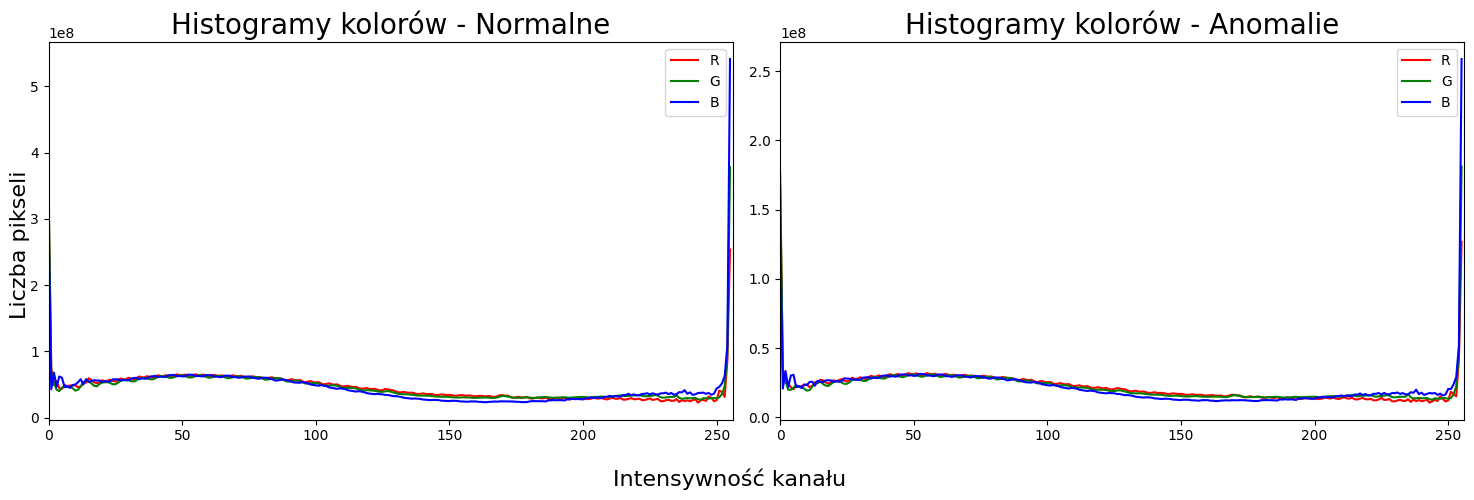

In [5]:
from concurrent.futures import ThreadPoolExecutor
import os
import matplotlib.pyplot as plt
import seaborn as sns

train_labels = train_dataset.labels

normal_indices = torch.where(train_labels == 0)[0]
anomaly_indices = torch.where(train_labels != 0)[0]

def calculate_histograms(indices, dataset, desc=None):
    hist_r = torch.zeros(256)
    hist_g = torch.zeros(256)
    hist_b = torch.zeros(256)
    for i in tqdm(indices, desc=desc, leave=False):
        img = dataset[i][0]
        hist_r += torch.histc(img[0], bins=256, min=0, max=1)
        hist_g += torch.histc(img[1], bins=256, min=0, max=1)
        hist_b += torch.histc(img[2], bins=256, min=0, max=1)
    return hist_r, hist_g, hist_b

# Podziel indeksy na mniejsze partie
def split_indices(indices, n_chunks=os.cpu_count()):
    return np.array_split(indices, n_chunks)

# Zrównoleglone obliczenia
with ThreadPoolExecutor(max_workers=os.cpu_count()) as executor:
    # Podziel indeksy na partie
    normal_chunks = split_indices(normal_indices)
    anomaly_chunks = split_indices(anomaly_indices)
    
    # Oblicz średnie dla każdej partii
    normal_results = list(executor.map(lambda chunk: calculate_histograms(chunk, train_dataset), normal_chunks))
    anomaly_results = list(executor.map(lambda chunk: calculate_histograms(chunk, train_dataset), anomaly_chunks))

normal_hist_r = torch.zeros(256)
normal_hist_g = torch.zeros(256)
normal_hist_b = torch.zeros(256)

anomaly_hist_r = torch.zeros(256)
anomaly_hist_g = torch.zeros(256)
anomaly_hist_b = torch.zeros(256)

for r, g, b in normal_results:
    normal_hist_r += r
    normal_hist_g += g
    normal_hist_b += b

for r, g, b in anomaly_results:
    anomaly_hist_r += r
    anomaly_hist_g += g
    anomaly_hist_b += b

# Wizualizacja histogramów
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

# Wykres dla obrazów normalnych
axs[0].plot(range(256), normal_hist_r.numpy(), color='red', label='R')
axs[0].plot(range(256), normal_hist_g.numpy(), color='green', label='G')
axs[0].plot(range(256), normal_hist_b.numpy(), color='blue', label='B')
axs[0].set_title('Histogramy kolorów - Normalne', fontsize=20)
axs[0].set_xlim([0, 256])
axs[0].legend()

# Wykres dla anomalii
axs[1].plot(range(256), anomaly_hist_r.numpy(), color='red', label='R')
axs[1].plot(range(256), anomaly_hist_g.numpy(), color='green', label='G')
axs[1].plot(range(256), anomaly_hist_b.numpy(), color='blue', label='B')
axs[1].set_title('Histogramy kolorów - Anomalie', fontsize=20)
axs[1].set_xlim([0, 256])
axs[1].legend()

fig.supxlabel("Intensywność kanału", fontsize=16)
fig.supylabel("Liczba pikseli", fontsize=16)

plt.tight_layout()
plt.show()

  0%|          | 0/11275 [00:00<?, ?it/s]

  0%|          | 0/11274 [00:00<?, ?it/s]

  0%|          | 0/11274 [00:00<?, ?it/s]

  0%|          | 0/11274 [00:00<?, ?it/s]

  0%|          | 0/11274 [00:00<?, ?it/s]

...

  0%|          | 0/120 [00:00<?, ?it/s]

  0%|          | 0/121 [00:00<?, ?it/s]

  0%|          | 0/120 [00:00<?, ?it/s]

  0%|          | 0/120 [00:00<?, ?it/s]

  0%|          | 0/120 [00:00<?, ?it/s]

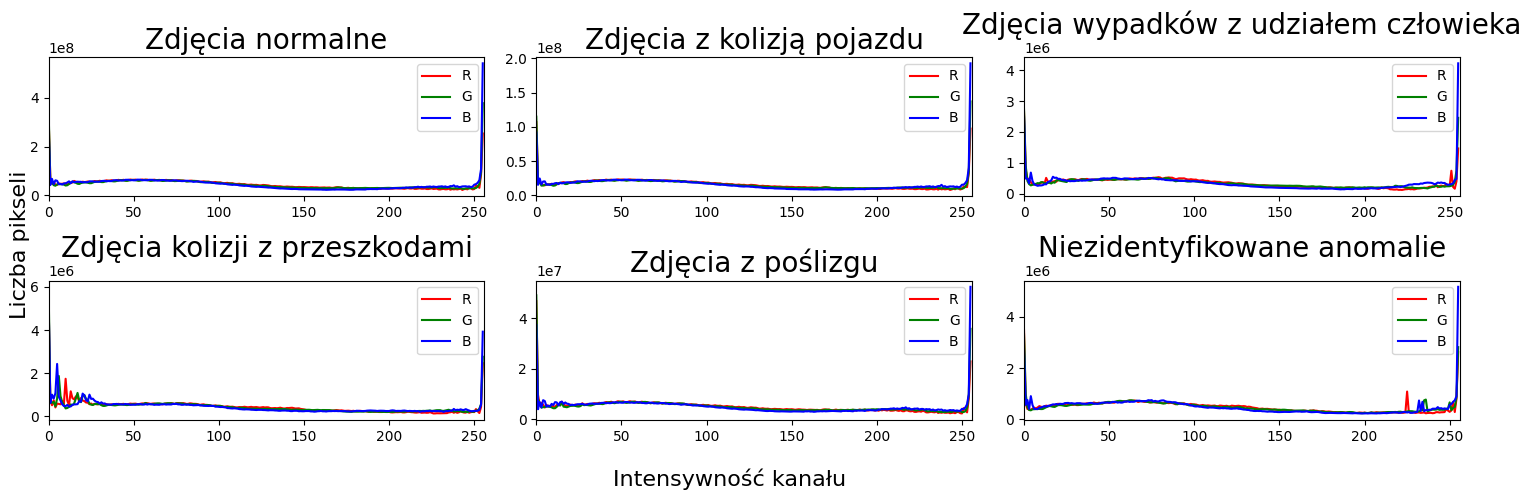

In [7]:
from concurrent.futures import ThreadPoolExecutor
import os
import matplotlib.pyplot as plt
import seaborn as sns

train_labels = train_dataset.labels

normal_indices = torch.where(train_labels == 0)[0]
car_crush_indices = torch.where(train_labels == 1)[0]
human_indices = torch.where(train_labels == 2)[0]
obstacle_indices = torch.where(train_labels == 3)[0]
offroad_indices = torch.where(train_labels == 4)[0]
unknown_indices = torch.where(train_labels == 5)[0]

def calculate_histograms(indices, dataset, desc=None):
    hist_r = torch.zeros(256)
    hist_g = torch.zeros(256)
    hist_b = torch.zeros(256)
    for i in tqdm(indices, desc=desc, leave=False):
        img = dataset[i][0]
        hist_r += torch.histc(img[0], bins=256, min=0, max=1)
        hist_g += torch.histc(img[1], bins=256, min=0, max=1)
        hist_b += torch.histc(img[2], bins=256, min=0, max=1)
    return hist_r, hist_g, hist_b

# Podziel indeksy na mniejsze partie
def split_indices(indices, n_chunks=os.cpu_count()):
    return np.array_split(indices, n_chunks)

# Zrównoleglone obliczenia
with ThreadPoolExecutor(max_workers=os.cpu_count()) as executor:
    # Podziel indeksy na partie
    normal_chunks = split_indices(normal_indices)
    car_crush_chunks = split_indices(car_crush_indices)
    human_chunks = split_indices(human_indices)
    obstacle_chunks = split_indices(obstacle_indices)
    offroad_chunks = split_indices(offroad_indices)
    unknown_chunks = split_indices(unknown_indices)
    
    # Oblicz średnie dla każdej partii
    normal_results = list(executor.map(lambda chunk: calculate_histograms(chunk, train_dataset), normal_chunks))
    car_crush_results = list(executor.map(lambda chunk: calculate_histograms(chunk, train_dataset), car_crush_chunks))
    human_results = list(executor.map(lambda chunk: calculate_histograms(chunk, train_dataset), human_chunks))
    obstacle_results = list(executor.map(lambda chunk: calculate_histograms(chunk, train_dataset), obstacle_chunks))
    offroad_results = list(executor.map(lambda chunk: calculate_histograms(chunk, train_dataset), offroad_chunks))
    unknown_results = list(executor.map(lambda chunk: calculate_histograms(chunk, train_dataset), unknown_chunks))

normal_hist_r = torch.zeros(256)
normal_hist_g = torch.zeros(256)
normal_hist_b = torch.zeros(256)

car_crush_hist_r = torch.zeros(256)
car_crush_hist_g = torch.zeros(256)
car_crush_hist_b = torch.zeros(256)

human_hist_r = torch.zeros(256)
human_hist_g = torch.zeros(256)
human_hist_b = torch.zeros(256)

obstacle_hist_r = torch.zeros(256)
obstacle_hist_g = torch.zeros(256)
obstacle_hist_b = torch.zeros(256)

offroad_hist_r = torch.zeros(256)
offroad_hist_g = torch.zeros(256)
offroad_hist_b = torch.zeros(256)

unknown_hist_r = torch.zeros(256)
unknown_hist_g = torch.zeros(256)
unknown_hist_b = torch.zeros(256)

for r, g, b in normal_results:
    normal_hist_r += r
    normal_hist_g += g
    normal_hist_b += b

for r, g, b in car_crush_results:
    car_crush_hist_r += r
    car_crush_hist_g += g
    car_crush_hist_b += b

for r, g, b in human_results:
    human_hist_r += r
    human_hist_g += g
    human_hist_b += b

for r, g, b in obstacle_results:
    obstacle_hist_r += r
    obstacle_hist_g += g
    obstacle_hist_b += b

for r, g, b in offroad_results:
    offroad_hist_r += r
    offroad_hist_g += g
    offroad_hist_b += b

for r, g, b in unknown_results:
    unknown_hist_r += r
    unknown_hist_g += g
    unknown_hist_b += b

# Wizualizacja histogramów
fig, axs = plt.subplots(2, 3, figsize=(15, 5))

# Wykres dla obrazów normalnych
axs[0, 0].plot(range(256), normal_hist_r.numpy(), color='red', label='R')
axs[0, 0].plot(range(256), normal_hist_g.numpy(), color='green', label='G')
axs[0, 0].plot(range(256), normal_hist_b.numpy(), color='blue', label='B')
axs[0, 0].set_title('Zdjęcia normalne', fontsize=20)
axs[0, 0].set_xlim([0, 256])
axs[0, 0].legend()

axs[0, 1].plot(range(256), car_crush_hist_r.numpy(), color='red', label='R')
axs[0, 1].plot(range(256), car_crush_hist_g.numpy(), color='green', label='G')
axs[0, 1].plot(range(256), car_crush_hist_b.numpy(), color='blue', label='B')
axs[0, 1].set_title('Zdjęcia z kolizją pojazdu', fontsize=20)
axs[0, 1].set_xlim([0, 256])
axs[0, 1].legend()

axs[0, 2].plot(range(256), human_hist_r.numpy(), color='red', label='R')
axs[0, 2].plot(range(256), human_hist_g.numpy(), color='green', label='G')
axs[0, 2].plot(range(256), human_hist_b.numpy(), color='blue', label='B')
axs[0, 2].set_title('Zdjęcia wypadków z udziałem człowieka', fontsize=20)
axs[0, 2].set_xlim([0, 256])
axs[0, 2].legend()

axs[1, 0].plot(range(256), obstacle_hist_r.numpy(), color='red', label='R')
axs[1, 0].plot(range(256), obstacle_hist_g.numpy(), color='green', label='G')
axs[1, 0].plot(range(256), obstacle_hist_b.numpy(), color='blue', label='B')
axs[1, 0].set_title('Zdjęcia kolizji z przeszkodami', fontsize=20)
axs[1, 0].set_xlim([0, 256])
axs[1, 0].legend()

axs[1, 1].plot(range(256), offroad_hist_r.numpy(), color='red', label='R')
axs[1, 1].plot(range(256), offroad_hist_g.numpy(), color='green', label='G')
axs[1, 1].plot(range(256), offroad_hist_b.numpy(), color='blue', label='B')
axs[1, 1].set_title('Zdjęcia z poślizgu', fontsize=20)
axs[1, 1].set_xlim([0, 256])
axs[1, 1].legend()

# Wykres dla anomalii
axs[1, 2].plot(range(256), unknown_hist_r.numpy(), color='red', label='R')
axs[1, 2].plot(range(256), unknown_hist_g.numpy(), color='green', label='G')
axs[1, 2].plot(range(256), unknown_hist_b.numpy(), color='blue', label='B')
axs[1, 2].set_title('Niezidentyfikowane anomalie', fontsize=20)
axs[1, 2].set_xlim([0, 256])
axs[1, 2].legend()

fig.supxlabel("Intensywność kanału", fontsize=16)
fig.supylabel("Liczba pikseli", fontsize=16)

plt.tight_layout()
plt.show()

### Contrast and intensity

[Go back](#back)

### Blur

Jak interpretować wygenerowany wykres?
Wykres ten pozwala na szybką ocenę charakterystyki Twojego zbioru danych:

Dolny lewy róg: Filmy stale rozmyte. (Niska mediana ostrości, niska zmienność). Mogą to być nagrania nocne, w złej pogodzie lub z kamery o słabej jakości.

Dolny prawy róg: Filmy stale ostre. (Wysoka mediana ostrości, niska zmienność). Prawdopodobnie nagrania dzienne, w dobrych warunkach, ze stabilnej kamery.

Górny lewy róg: Filmy o niskiej średniej ostrości, ale bardzo zmiennej. (Niska mediana, wysoka zmienność). Może to oznaczać, że kamera próbuje (bezskutecznie) złapać ostrość w trudnych warunkach.

Górny prawy róg: Filmy o wysokiej średniej ostrości, ale bardzo zmiennej. (Wysoka mediana, wysoka zmienność). To może być charakterystyczne dla dynamicznych scen, gdzie kamera szybko zmienia focus między bliskimi a dalekimi obiektami.

Analizując rozmieszczenie kolorów (klas), możesz odpowiedzieć na pytania:

Czy filmy z kolizjami (Kolizja pojazdu) grupują się w lewym dolnym rogu? Oznaczałoby to, że są one zazwyczaj bardziej rozmyte (np. z powodu ruchu, dymu, słabego oświetlenia).

Czy normalne filmy (Normalne) znajdują się głównie w prawym dolnym rogu (są ostre i stabilne)?

Czy jakaś klasa ma wyraźnie większe odchylenie standardowe (jest wyżej na osi Y), co sugeruje problemy z autofokusem w tych scenariuszach?

[Go back](#back)

Znaleziono 3275 plików z adnotacjami w zestawie 'train'. Rozpoczynanie analizy...


Analizowanie wideo:   0%|          | 0/3275 [00:00<?, ?it/s]


Zakończono analizę. Zebrano dane dla 3275 wideo. Generowanie wykresu...


C:\Users\lukas\AppData\Local\Temp\ipykernel_43620\3467427935.py:140: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('turbo', len(CLASS_NAMES))


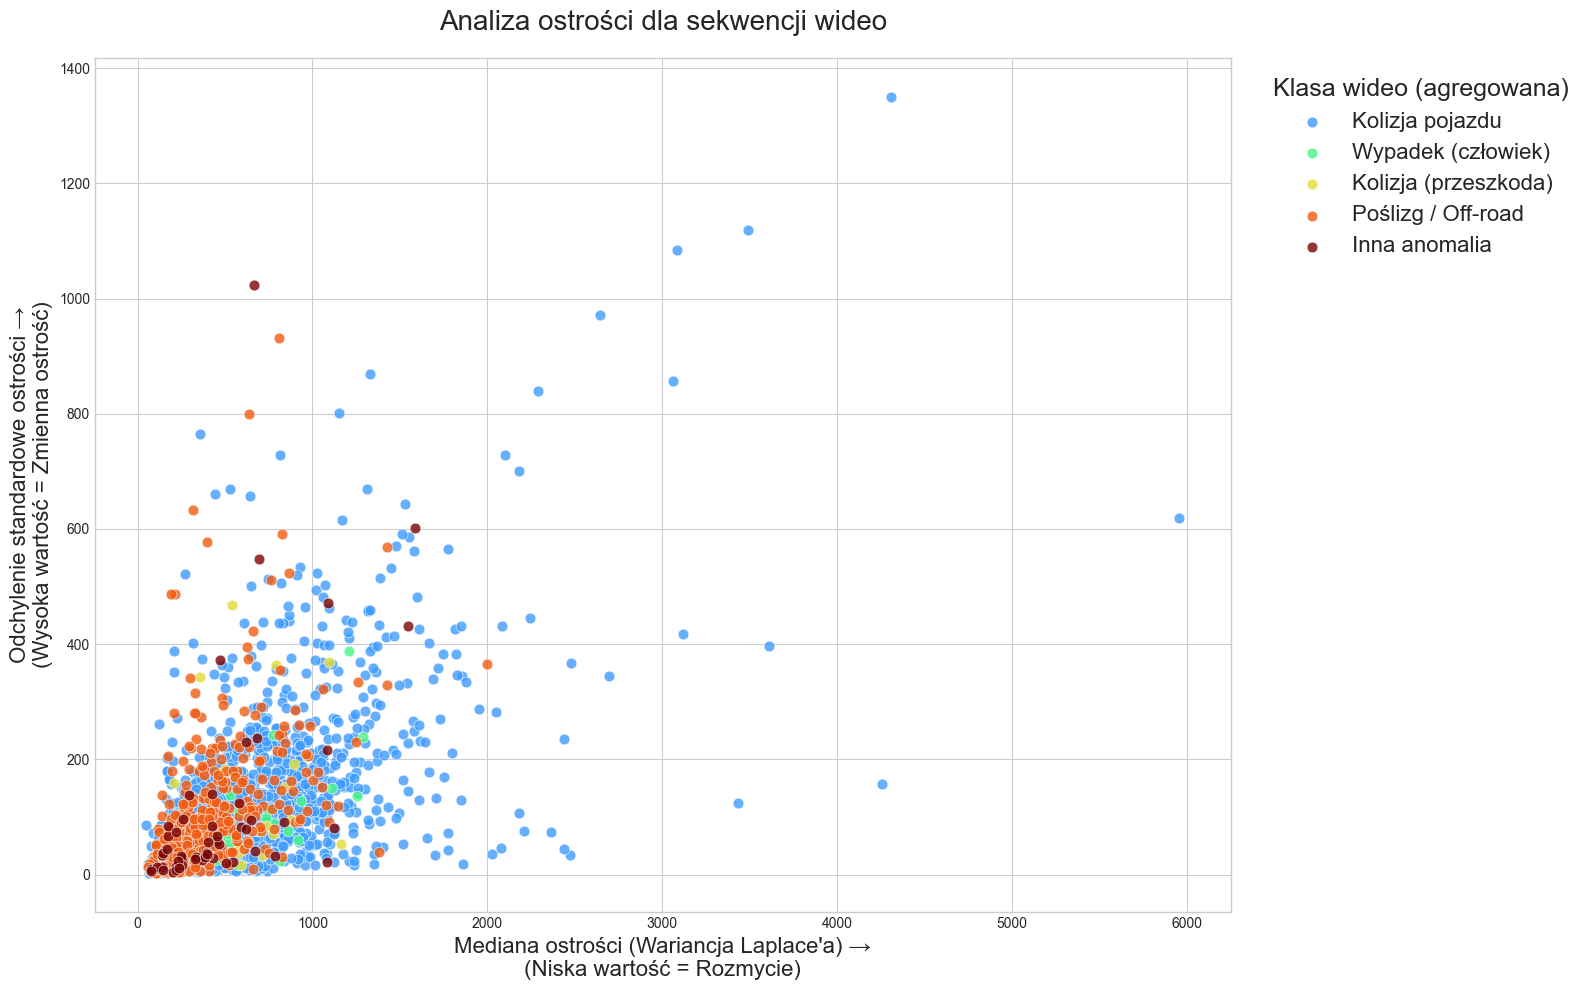

In [1]:
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from concurrent.futures import ThreadPoolExecutor
import os

# --- 1. Funkcje pomocnicze ---

def calculate_frame_sharpness(frame_bgr):
    """
    Oblicza ostrość obrazu za pomocą wariancji transformaty Laplace'a.
    """
    if frame_bgr is None:
        return 0.0
    gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)
    sharpness_score = cv2.Laplacian(gray, cv2.CV_64F).var()
    return sharpness_score

def map_accident_id(original_id):
    """
    Mapuje oryginalne ID wypadku na uproszczone ID klas.
    """
    if original_id == 0:
        return 0
    elif original_id in [1, 2, 3, 4, 5]:
        return 1
    elif original_id == 6:
        return 2
    elif original_id == 7:
        return 3
    elif original_id in [8, 9]:
        return 4
    elif original_id == 10:
        return 5
    else:
        return -1

# --- 2. Funkcja-worker do przetwarzania jednego wideo ---
def process_video_file(label_path, frames_dir_path):
    """
    Przetwarza jedno wideo (jeden plik .json), oblicza metryki rozmycia i zwraca wynik.
    Zaprojektowana do uruchamiania w osobnym wątku.
    """
    try:
        with open(label_path, 'r', encoding='utf-8') as f:
            labels_data = json.load(f)
    except (json.JSONDecodeError, FileNotFoundError):
        #print(f"Błąd odczytu pliku {label_path.name}: {e}")
        return None

    if "labels" not in labels_data:
        return None

    # Krok 1: Zbierz ścieżki do klatek i etykiety dla wideo
    current_video_frame_paths = []
    current_video_frame_labels = []

    for label_info in labels_data["labels"]:
        image_path_suffix = label_info.get('image_path')
        if not image_path_suffix:
            continue

        image_path = frames_dir_path / image_path_suffix.replace("frames/", "")
        
        if not image_path.exists():
            continue
            
        original_id = label_info.get('accident_id', -1)
        mapped_id = map_accident_id(original_id)
        
        if mapped_id != -1:
            current_video_frame_paths.append(image_path)
            current_video_frame_labels.append(mapped_id)

    if not current_video_frame_paths:
        return None

    # Krok 2: Ustal zbiorczą etykietę dla wideo
    video_label = max(current_video_frame_labels)

    # Krok 3: Oblicz wskaźniki ostrości
    sharpness_scores = [calculate_frame_sharpness(cv2.imread(str(p))) for p in current_video_frame_paths]

    # Krok 4: Oblicz metryki i zwróć wynik
    if sharpness_scores:
        return {
            'id': label_path.stem,
            'median_sharpness': np.median(sharpness_scores),
            'std_dev_sharpness': np.std(sharpness_scores),
            'label': video_label
        }
    return None

# --- 3. Główna część skryptu ---

if __name__ == "__main__":
    # Konfiguracja
    PATH_TO_DATA = Path('D:/MAGISTERKA/anomaly_traffic_road/datasets/DoTA')
    WHICH_SET = 'train'
    
    annotations_dir = PATH_TO_DATA / 'annotations' / WHICH_SET
    frames_dir = PATH_TO_DATA / 'frames' / WHICH_SET

    CLASS_NAMES = {
        0: 'Normalne', 1: 'Kolizja pojazdu', 2: 'Wypadek (człowiek)',
        3: 'Kolizja (przeszkoda)', 4: 'Poślizg / Off-road', 5: 'Inna anomalia'
    }

    label_paths = list(annotations_dir.rglob('*.json'))
    print(f"Znaleziono {len(label_paths)} plików z adnotacjami w zestawie '{WHICH_SET}'. Rozpoczynanie analizy...")

    # Przetwarzanie wielowątkowe
    video_level_metrics = []
    # Używamy os.cpu_count() do dynamicznego ustawienia liczby wątków
    with ThreadPoolExecutor(max_workers=os.cpu_count()) as executor:
        # Tworzymy iterator, który będzie uruchamiał naszą funkcję w wątkach
        # lambda jest używana, aby przekazać stały argument 'frames_dir' do funkcji workera
        results_iterator = executor.map(lambda p: process_video_file(p, frames_dir), label_paths)
        
        # Używamy tqdm do śledzenia postępu na iteratorze
        for result in tqdm(results_iterator, total=len(label_paths), desc="Analizowanie wideo"):
            if result is not None:
                video_level_metrics.append(result)

    # Wizualizacja wyników
    if not video_level_metrics:
        print("Nie udało się zebrać danych. Sprawdź ścieżki i strukturę plików.")
    else:
        print(f"\nZakończono analizę. Zebrano dane dla {len(video_level_metrics)} wideo. Generowanie wykresu...")
        median_list = [m['median_sharpness'] for m in video_level_metrics]
        std_dev_list = [m['std_dev_sharpness'] for m in video_level_metrics]
        labels_list = [m['label'] for m in video_level_metrics]
        unique_labels = sorted(list(set(labels_list)))

        plt.style.use('seaborn-v0_8-whitegrid')
        fig, ax = plt.subplots(figsize=(16, 10))
        colors = plt.cm.get_cmap('turbo', len(CLASS_NAMES))

        for i, label_id in enumerate(unique_labels):
            class_mask = [l == label_id for l in labels_list]
            x = [b for b, m in zip(median_list, class_mask) if m]
            y = [s for s, m in zip(std_dev_list, class_mask) if m]
            
            ax.scatter(x, y, color=colors(label_id), label=CLASS_NAMES.get(label_id), alpha=0.8, s=60, edgecolors='w', linewidth=0.5)

        ax.set_title('Analiza ostrości dla sekwencji wideo', fontsize=20, pad=20)
        ax.set_xlabel('Mediana ostrości (Wariancja Laplace\'a) →\n(Niska wartość = Rozmycie)', fontsize=16)
        ax.set_ylabel('Odchylenie standardowe ostrości →\n(Wysoka wartość = Zmienna ostrość)', fontsize=16)
        ax.legend(title='Klasa wideo (agregowana)', fontsize=16, title_fontsize=18, bbox_to_anchor=(1.02, 1), loc='upper left')
        plt.tight_layout()

        plt.show()

### Grayscale intensity distribution

[Go back](#back)

Przetwarzanie klasy: Normal...


  0%|          | 0/11275 [00:00<?, ?it/s]

  0%|          | 0/11274 [00:00<?, ?it/s]

  0%|          | 0/11274 [00:00<?, ?it/s]

  0%|          | 0/11274 [00:00<?, ?it/s]

...

  0%|          | 0/5471 [00:00<?, ?it/s]

  0%|          | 0/5471 [00:00<?, ?it/s]

  0%|          | 0/5471 [00:00<?, ?it/s]

  0%|          | 0/5471 [00:00<?, ?it/s]

  0%|          | 0/5471 [00:12<?, ?it/s]

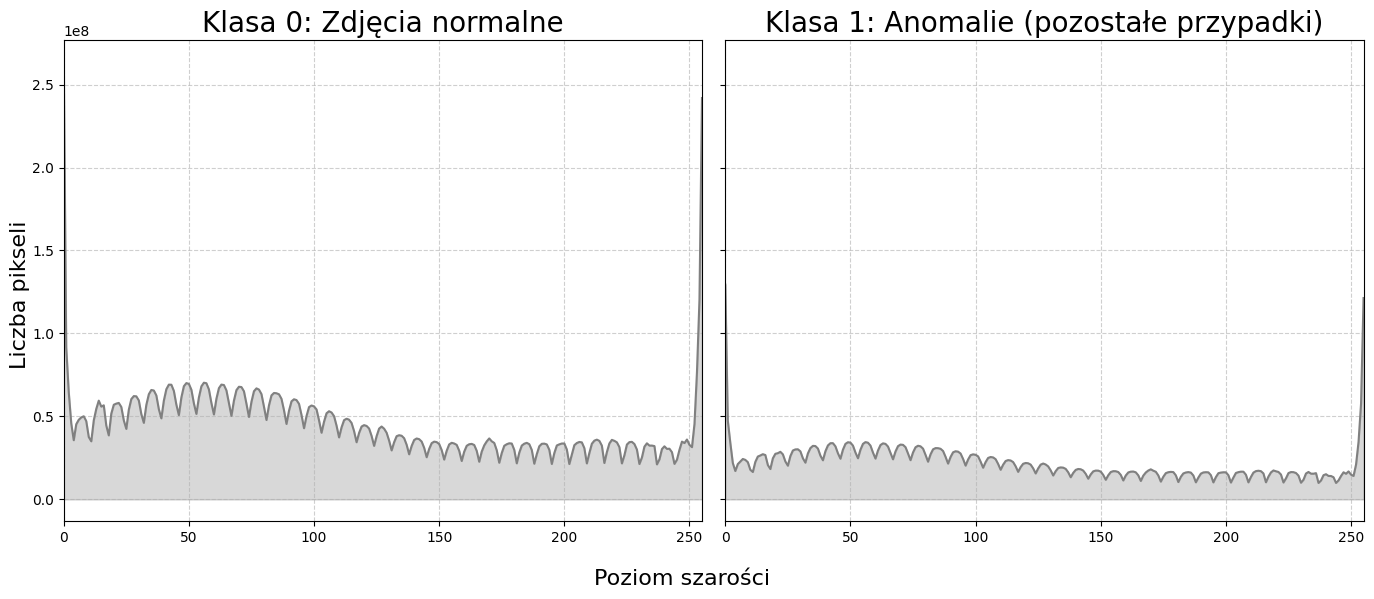

In [6]:
import torch
from torchvision.transforms.functional import rgb_to_grayscale
from concurrent.futures import ThreadPoolExecutor
import os
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# Założenie: train_dataset jest obiektem klasy Dataset z PyTorch
# train_dataset.labels jest tensorem zawierającym etykiety
# Przykład:
# from torchvision.datasets import FakeData
# from torchvision import transforms
# train_dataset = FakeData(size=1000, image_size=(3, 224, 224), num_classes=6, transform=transforms.ToTensor())
# train_dataset.labels = torch.randint(0, 6, (1000,))

train_labels = train_dataset.labels

# ZMIANA: Definiowanie indeksów dla klasyfikacji binarnej
# Klasa 0: "Normal"
normal_indices = torch.where(train_labels == 0)[0]

# Klasa 1: "Anomalia" - wszystkie pozostałe przypadki (etykiety > 0)
anomaly_indices = torch.where(train_labels > 0)[0]


# Funkcja obliczająca histogram (bez zmian)
def calculate_grayscale_histograms(indices, dataset, desc=None):
    """
    Konwertuje obrazy na skalę szarości i oblicza ich zagregowany histogram.
    """
    hist_gray = torch.zeros(256)
    for i in tqdm(indices, desc=desc, leave=False):
        color_img = dataset[i][0]
        gray_img = rgb_to_grayscale(color_img)
        hist_gray += torch.histc(gray_img, bins=256, min=0, max=1)
    return hist_gray

# Funkcja pomocnicza do podziału indeksów (bez zmian)
def split_indices(indices, n_chunks=os.cpu_count()):
    return np.array_split(indices, n_chunks)

# ZMIANA: Uproszczony słownik dla klas binarnych
class_indices = {
    "Normal": normal_indices,
    "Anomalia": anomaly_indices,
}

# Słownik do przechowywania zagregowanych histogramów
histograms = {}

# Zrównoleglone obliczenia (logika pętli bez zmian, ale wykona się tylko 2 razy)
with ThreadPoolExecutor(max_workers=os.cpu_count()) as executor:
    for class_name, indices in class_indices.items():
        print(f"Przetwarzanie klasy: {class_name}...")
        if len(indices) == 0:
            print(f"Brak próbek dla klasy {class_name}, pomijanie.")
            histograms[class_name] = torch.zeros(256)
            continue
            
        chunks = split_indices(indices)
        
        results = list(executor.map(lambda chunk: calculate_grayscale_histograms(chunk, train_dataset), chunks))
        
        if results:
            total_hist = torch.sum(torch.stack(results), dim=0)
            histograms[class_name] = total_hist
        else:
            histograms[class_name] = torch.zeros(256)


# ZMIANA: Wizualizacja dla dwóch klas
fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharey=True) # 1 wiersz, 2 kolumny, współdzielona oś Y

# Mapowanie nazw klas na tytuły wykresów
titles = {
    "Normal": 'Klasa 0: Zdjęcia normalne',
    "Anomalia": 'Klasa 1: Anomalie (pozostałe przypadki)'
}

# Wykres dla klasy "Normal"
ax1 = axs[0]
hist_normal = histograms["Normal"]
ax1.plot(range(256), hist_normal.numpy(), color='gray')
ax1.fill_between(range(256), hist_normal.numpy(), color='gray', alpha=0.3)
ax1.set_title(titles["Normal"], fontsize=20)
ax1.set_xlim([0, 255])
ax1.grid(True, linestyle='--', alpha=0.6)

# Wykres dla klasy "Anomalia"
ax2 = axs[1]
hist_anomaly = histograms["Anomalia"]
ax2.plot(range(256), hist_anomaly.numpy(), color='gray')
ax2.fill_between(range(256), hist_anomaly.numpy(), color='gray', alpha=0.3)
ax2.set_title(titles["Anomalia"], fontsize=20)
ax2.set_xlim([0, 255])
ax2.grid(True, linestyle='--', alpha=0.6)


fig.supxlabel("Poziom szarości", fontsize=16)
fig.supylabel("Liczba pikseli", fontsize=16)
plt.tight_layout()
plt.show()

Przetwarzanie klasy: Normal...


  0%|          | 0/11275 [00:00<?, ?it/s]

  0%|          | 0/11274 [00:00<?, ?it/s]

  0%|          | 0/11275 [00:00<?, ?it/s]

  0%|          | 0/11274 [00:00<?, ?it/s]

...

  0%|          | 0/120 [00:00<?, ?it/s]

  0%|          | 0/120 [00:00<?, ?it/s]

  0%|          | 0/121 [00:00<?, ?it/s]

  0%|          | 0/120 [00:00<?, ?it/s]

  0%|          | 0/120 [00:00<?, ?it/s]

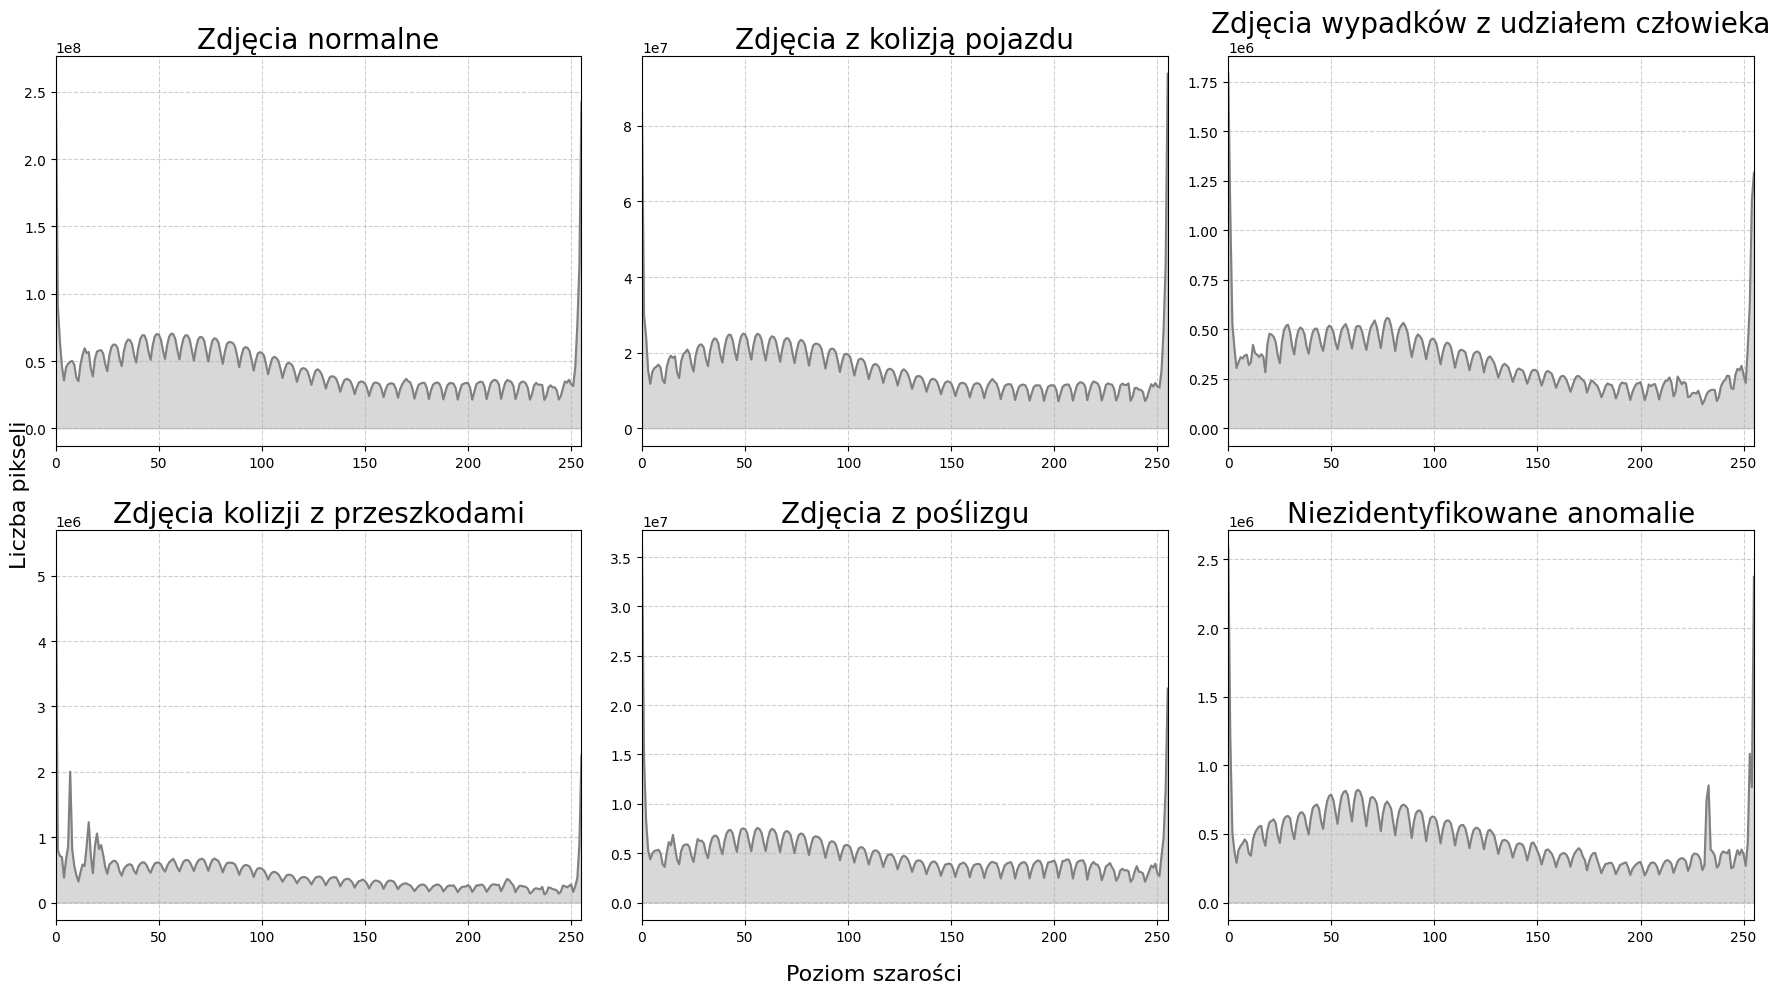

In [5]:
import torch
from concurrent.futures import ThreadPoolExecutor
import os
import matplotlib.pyplot as plt
from tqdm.auto import tqdm # Lepszy pasek postępu dla notebooków i skryptów

# Założenie: train_dataset jest obiektem klasy Dataset z PyTorch
# train_dataset.labels jest tensorem zawierającym etykiety
# Przykład:
# from torchvision.datasets import FakeData
# from torchvision import transforms
# train_dataset = FakeData(size=1000, image_size=(3, 224, 224), num_classes=6, transform=transforms.ToTensor())
# train_dataset.labels = torch.randint(0, 6, (1000,))

train_labels = train_dataset.labels

# Znajdowanie indeksów dla każdej z klas
normal_indices = torch.where(train_labels == 0)[0]
car_crush_indices = torch.where(train_labels == 1)[0]
human_indices = torch.where(train_labels == 2)[0]
obstacle_indices = torch.where(train_labels == 3)[0]
offroad_indices = torch.where(train_labels == 4)[0]
unknown_indices = torch.where(train_labels == 5)[0]

# NOWA FUNKCJA: Oblicza histogram dla obrazów w skali szarości
def calculate_grayscale_histograms(indices, dataset, desc=None):
    """
    Konwertuje obrazy na skalę szarości i oblicza ich zagregowany histogram.
    """
    # Inicjalizujemy pojedynczy histogram dla skali szarości
    hist_gray = torch.zeros(256)
    
    for i in tqdm(indices, desc=desc, leave=False):
        # Pobieramy obraz kolorowy (zakładamy, że jest to tensor C, H, W)
        color_img = dataset[i][0]
        
        # Konwertujemy obraz do skali szarości
        # Wynikiem jest tensor (1, H, W)
        gray_img = rgb_to_grayscale(color_img)
        
        # Obliczamy histogram dla kanału szarości.
        # Zakładamy, że wartości pikseli są znormalizowane do zakresu [0, 1].
        # Jeśli są w zakresie [0, 255], zmień max=1 na max=255.
        hist_gray += torch.histc(gray_img, bins=256, min=0, max=1)
        
    return hist_gray

# Funkcja pomocnicza do podziału indeksów na partie
def split_indices(indices, n_chunks=os.cpu_count()):
    return np.array_split(indices, n_chunks)

# Słownik do przechowywania indeksów i późniejszych wyników
class_indices = {
    "Normal": normal_indices,
    "Car Crush": car_crush_indices,
    "Human": human_indices,
    "Obstacle": obstacle_indices,
    "Offroad": offroad_indices,
    "Unknown": unknown_indices,
}

# Słownik do przechowywania zagregowanych histogramów
histograms = {}

# Zrównoleglone obliczenia dla każdej klasy
with ThreadPoolExecutor(max_workers=os.cpu_count()) as executor:
    for class_name, indices in class_indices.items():
        print(f"Przetwarzanie klasy: {class_name}...")
        # Podziel indeksy na partie
        chunks = split_indices(indices)
        
        # Oblicz histogramy dla każdej partii równolegle
        results = list(executor.map(lambda chunk: calculate_grayscale_histograms(chunk, train_dataset), chunks))
        
        # Zagreguj wyniki z wszystkich partii dla danej klasy
        if results:
            total_hist = torch.sum(torch.stack(results), dim=0)
            histograms[class_name] = total_hist
        else:
            histograms[class_name] = torch.zeros(256)


# Wizualizacja histogramów
fig, axs = plt.subplots(2, 3, figsize=(18, 10))
axs = axs.flatten()  # Spłaszczenie tablicy osi dla łatwiejszej iteracji

# Mapowanie nazw klas na tytuły wykresów
titles = {
    "Normal": 'Zdjęcia normalne',
    "Car Crush": 'Zdjęcia z kolizją pojazdu',
    "Human": 'Zdjęcia wypadków z udziałem człowieka',
    "Obstacle": 'Zdjęcia kolizji z przeszkodami',
    "Offroad": 'Zdjęcia z poślizgu',
    "Unknown": 'Niezidentyfikowane anomalie'
}

for i, (class_name, hist) in enumerate(histograms.items()):
    ax = axs[i]
    # Rysujemy histogram skali szarości
    ax.plot(range(256), hist.numpy(), color='gray')
    ax.fill_between(range(256), hist.numpy(), color='gray', alpha=0.3) # Wypełnienie pod wykresem
    
    ax.set_title(titles[class_name], fontsize=20)
    ax.set_xlim([0, 255])
    ax.grid(True, linestyle='--', alpha=0.6)

# Ustawienie wspólnych etykiet dla całego rysunku
fig.supxlabel("Poziom szarości", fontsize=16)
fig.supylabel("Liczba pikseli", fontsize=16)

plt.tight_layout() # Dopasowanie układu i dodanie miejsca na super-tytuł
plt.show()

### Optical flow analysis

Jak interpretować nowy wykres:
Wykres ten dostarcza bezcennych informacji o dynamice scen w Twoim zbiorze danych.

Dolny lewy róg: Filmy o niskim i stałym ruchu. Prawdopodobnie są to nagrania ze stacjonarnej kamery monitoringu pokazujące spokojną scenę, np. pustą drogę lub parking w nocy. Spodziewamy się tu głównie filmów z klasy Normalne.

Dolny prawy róg: Filmy o dużym, ale stałym i przewidywalnym ruchu. Idealnym przykładem jest nagranie z dashcamu jadącego ze stałą prędkością po autostradzie. Ruch jest duży (cała scena się przesuwa), ale jego charakterystyka jest stała.

Górna część wykresu (wysoka wartość Y): To najciekawszy obszar. Znajdują się tu filmy o bardzo zmiennym, nieregularnym ruchu.

Górny prawy róg: Duży średni ruch i duża zmienność. To główni "podejrzani" o zawieranie kolizji, gwałtownych manewrów czy poślizgów. Nagły wstrząs kamery, obrót pojazdu – wszystko to generuje wysokie wartości na obu osiach.

Górny lewy róg: Niski średni ruch, ale duża zmienność. Może to być np. scena, gdzie większość czasu nic się nie dzieje, ale nagle pojawia się pojedyncze, gwałtowne zdarzenie (np. pieszy wbiegający na drogę przed stojącym samochodem).

Analizując rozmieszczenie kolorowych punktów, możesz zweryfikować, czy klasy anomalii (Kolizja, Poślizg) faktycznie grupują się w prawej górnej części wykresu. Jeśli tak, to metryki oparte na przepływie optycznym będą doskonałymi cechami dla Twojego modelu klasyfikacyjnego.

[Go back](#back)

Znaleziono 3275 plików wideo. Rozpoczynanie analizy przepływu optycznego...


Analizowanie ruchu:   0%|          | 0/3275 [00:00<?, ?it/s]


Zakończono analizę. Zebrano dane dla 3275 wideo. Generowanie wykresu...


C:\Users\lukas\AppData\Local\Temp\ipykernel_50020\1258771850.py:138: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('turbo', len(CLASS_NAMES))


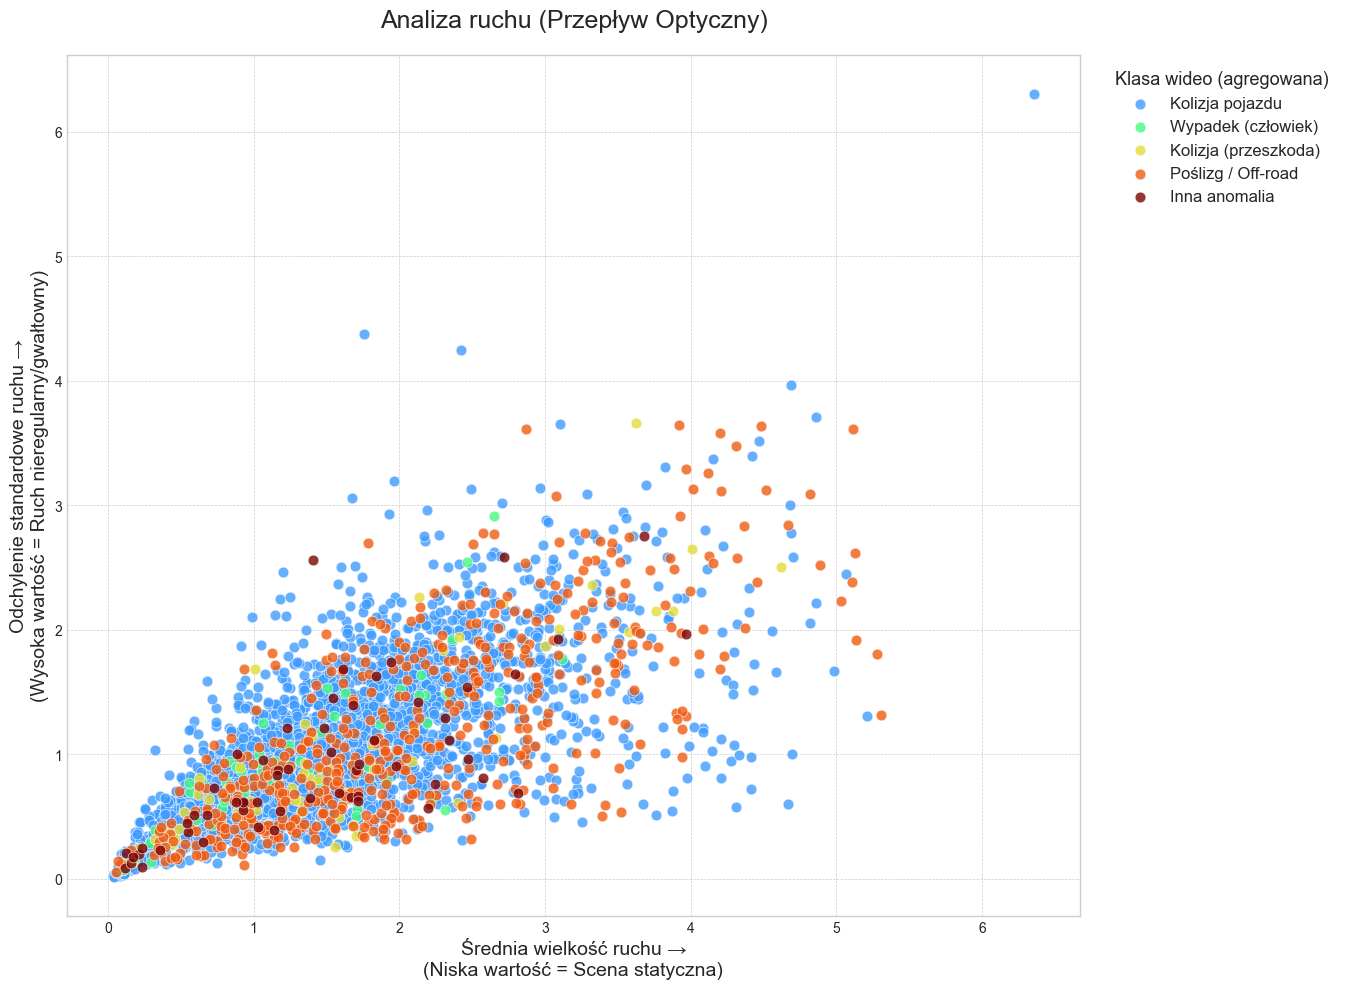

In [3]:
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm
from concurrent.futures import ThreadPoolExecutor
import os

# --- 1. Funkcje pomocnicze ---

def map_accident_id(original_id):
    """Mapuje oryginalne ID wypadku na uproszczone ID klas."""
    if original_id == 0: return 0
    elif original_id in [1, 2, 3, 4, 5]: return 1
    elif original_id == 6: return 2
    elif original_id == 7: return 3
    elif original_id in [8, 9]: return 4
    elif original_id == 10: return 5
    else: return -1

# --- 2. Funkcja-worker do analizy PRZEPŁYWU OPTYCZNEGO ---
def process_video_for_flow(label_path, frames_dir_path, resize_dim=(320, 240)):
    """
    Przetwarza jedno wideo (plik .json), oblicza metryki przepływu optycznego i zwraca wynik.
    Zaprojektowana do uruchamiania w osobnym wątku.
    """
    try:
        with open(label_path, 'r', encoding='utf-8') as f:
            labels_data = json.load(f)
    except (json.JSONDecodeError, FileNotFoundError):
        return None

    if "labels" not in labels_data or not labels_data["labels"]:
        return None

    # Krok 1: Posortuj klatki, aby zapewnić prawidłową kolejność czasową
    try:
        labels_data["labels"].sort(key=lambda x: x['image_path'])
    except KeyError:
        # Jeśli nie ma 'image_path', nie możemy zagwarantować kolejności
        return None

    # Krok 2: Zbierz ścieżki do klatek i etykiety
    frame_paths, frame_labels = [], []
    for label_info in labels_data["labels"]:
        image_path_suffix = label_info.get('image_path')
        if not image_path_suffix: continue

        image_path = frames_dir_path / image_path_suffix.replace("frames/", "")
        mapped_id = map_accident_id(label_info.get('accident_id', -1))
        
        if image_path.exists() and mapped_id != -1:
            frame_paths.append(image_path)
            frame_labels.append(mapped_id)

    if len(frame_paths) < 2: # Potrzebujemy co najmniej 2 klatek do obliczenia przepływu
        return None

    # Krok 3: Ustal zbiorczą etykietę dla wideo
    video_label = max(frame_labels)

    # Krok 4: Oblicz metryki przepływu optycznego
    motion_magnitudes = []
    
    # Wczytaj pierwszą klatkę
    prev_frame = cv2.imread(str(frame_paths[0]))
    if prev_frame is None: return None
    prev_gray = cv2.cvtColor(cv2.resize(prev_frame, resize_dim), cv2.COLOR_BGR2GRAY)

    # Iteruj od drugiej klatki
    for i in range(1, len(frame_paths)):
        current_frame = cv2.imread(str(frame_paths[i]))
        if current_frame is None: continue
        
        current_gray = cv2.cvtColor(cv2.resize(current_frame, resize_dim), cv2.COLOR_BGR2GRAY)
        
        # Oblicz gęsty przepływ optyczny (algorytm Farnebacka)
        flow = cv2.calcOpticalFlowFarneback(prev_gray, current_gray, None, 0.5, 3, 15, 3, 5, 1.2, 0)
        
        # Oblicz wielkość (magnitude) wektorów przepływu
        magnitude, _ = cv2.cartToPolar(flow[..., 0], flow[..., 1])
        
        # Zapisz średnią wielkość ruchu dla tej pary klatek
        motion_magnitudes.append(np.mean(magnitude))
        
        # Zaktualizuj poprzednią klatkę
        prev_gray = current_gray

    # Krok 5: Zwróć zagregowane metryki
    if motion_magnitudes:
        return {
            'id': label_path.stem,
            'mean_motion': np.mean(motion_magnitudes),
            'std_dev_motion': np.std(motion_magnitudes),
            'label': video_label
        }
    return None

# --- 3. Główna część skryptu ---
if __name__ == "__main__":
    # Konfiguracja
    PATH_TO_DATA = Path('D:/MAGISTERKA/anomaly_traffic_road/datasets/DoTA')
    WHICH_SET = 'train'
    
    annotations_dir = PATH_TO_DATA / 'annotations' / WHICH_SET
    frames_dir = PATH_TO_DATA / 'frames' / WHICH_SET

    CLASS_NAMES = {
        0: 'Normalne', 1: 'Kolizja pojazdu', 2: 'Wypadek (człowiek)',
        3: 'Kolizja (przeszkoda)', 4: 'Poślizg / Off-road', 5: 'Inna anomalia'
    }

    label_paths = list(annotations_dir.rglob('*.json'))
    print(f"Znaleziono {len(label_paths)} plików wideo. Rozpoczynanie analizy przepływu optycznego...")

    # Przetwarzanie wielowątkowe
    video_level_metrics = []
    with ThreadPoolExecutor(max_workers=os.cpu_count()) as executor:
        results_iterator = executor.map(lambda p: process_video_for_flow(p, frames_dir), label_paths)
        
        for result in tqdm(results_iterator, total=len(label_paths), desc="Analizowanie ruchu"):
            if result is not None:
                video_level_metrics.append(result)

    # Wizualizacja wyników
    if not video_level_metrics:
        print("Nie udało się zebrać danych. Sprawdź ścieżki i strukturę plików.")
    else:
        print(f"\nZakończono analizę. Zebrano dane dla {len(video_level_metrics)} wideo. Generowanie wykresu...")
        mean_list = [m['mean_motion'] for m in video_level_metrics]
        std_dev_list = [m['std_dev_motion'] for m in video_level_metrics]
        labels_list = [m['label'] for m in video_level_metrics]
        unique_labels = sorted(list(set(labels_list)))

        plt.style.use('seaborn-v0_8-whitegrid')
        fig, ax = plt.subplots(figsize=(16, 10))
        colors = plt.cm.get_cmap('turbo', len(CLASS_NAMES))

        for label_id in unique_labels:
            class_mask = [l == label_id for l in labels_list]
            x = [b for b, m in zip(mean_list, class_mask) if m]
            y = [s for s, m in zip(std_dev_list, class_mask) if m]
            
            ax.scatter(x, y, color=colors(label_id), label=CLASS_NAMES.get(label_id), alpha=0.8, s=60, edgecolors='w', linewidth=0.5)

        ax.set_title('Analiza ruchu (Przepływ Optyczny)', fontsize=18, pad=20)
        ax.set_xlabel('Średnia wielkość ruchu →\n(Niska wartość = Scena statyczna)', fontsize=14)
        ax.set_ylabel('Odchylenie standardowe ruchu →\n(Wysoka wartość = Ruch nieregularny/gwałtowny)', fontsize=14)
        ax.legend(title='Klasa wideo (agregowana)', fontsize=12, title_fontsize=13, bbox_to_anchor=(1.02, 1), loc='upper left')
        ax.grid(True, which='both', linestyle='--', linewidth=0.5)
        plt.tight_layout(rect=[0, 0, 0.85, 1])

        plt.show()